# 04 TrAISformer MLOps Replication (Region 1)

This notebook provides:
- Class-wise modular AIS preprocessing (paper-style filters)
- TrAISformer dataset export (`*.pkl`) compatible with `CEE_TrAISformer`
- MLflow tracking (loss, accuracy, params, artifacts, logs)
- Crash-safe resume (`last_checkpoint.pt`) and best model save
- Early stopping with max 50 epochs

Environment note:
Run from your target env before opening Jupyter:
`source ~/Desktop/Deepdarshk/code_source/env.bin/activate`

In [14]:
from pathlib import Path
import os, sys, json, pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

ROOT = Path('/home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_')
NOTEBOOK_DIR = ROOT / 'CEE-Replication' / 'Notebook'
TRAISFORMER_DIR = ROOT / 'CEE_TrAISformer'
REGION_DATA_DIR = ROOT / 'CEE-Replication' / 'traisformer_data' / 'region_1'
RUN_DIR = ROOT / 'CEE-Replication' / 'results' / 'region_1_trAISformer_mlops'

assert TRAISFORMER_DIR.exists(), TRAISFORMER_DIR
sys.path.insert(0, str(TRAISFORMER_DIR))
sys.path.insert(0, str(NOTEBOOK_DIR))
print('Using root:', ROOT)
print('Using src:', TRAISFORMER_DIR)
print('Run dir:', RUN_DIR)

Using root: /home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_
Using src: /home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE_TrAISformer
Run dir: /home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE-Replication/results/region_1_trAISformer_mlops


In [15]:
import datasets, models, trainers
from traisformer_mlops import (
    AISPreprocessor,
    PreprocessingConfig,
    ExportConfig,
    TrAISformerDataExporter,
    EarlyStoppingConfig,
    TrAISformerMLflowTrainer,
)

try:
    import mlflow
    print('mlflow version:', mlflow.__version__)
except Exception as e:
    print('mlflow not available. Install with: pip install mlflow')
    raise

mlflow version: 3.7.0


## 1) Preprocessing + Export (paper criteria)

Implemented filters:
- remove near coastline (`<1 nm`) if coastline polygons + shapely available
- split non-contiguous voyages (`max gap = 2h`)
- remove short voyages (`<20 msgs` or duration `<4h`)
- remove abnormal empirical speed (`>40 knots`)
- remove unrealistic SOG (`>=30 knots`) and moored/anchor-like rows
- downsample to 10 minutes
- split long voyages to max 20 hours

In [17]:
RUN_PREPROCESS = False  # heavy; set True for full preprocessing from parquet
parquet_path = NOTEBOOK_DIR / 'region_1_interpolated.parquet'
coastline_pickle = TRAISFORMER_DIR / 'data' / 'ct_dma' / 'dma_coastline_polygons.pkl'

if RUN_PREPROCESS:
    pre_cfg = PreprocessingConfig(
        max_gap_hours=2.0,
        min_voyage_messages=20,
        min_voyage_hours=4.0,
        max_empirical_speed_knots=40.0,
        max_sog_knots=30.0,
        downsample_minutes=10,
        max_seq_hours=20.0,
        keep_only_underway=True,
        coastline_min_nm=1.0,
    )
    pre = AISPreprocessor(pre_cfg)
    df_clean = pre.run(parquet_path=parquet_path, coastline_pickle=coastline_pickle)

    exporter = TrAISformerDataExporter(ExportConfig(max_sog=30.0, train_ratio=0.8, valid_ratio=0.1, seed=42))
    meta = exporter.export(df_clean, REGION_DATA_DIR)
    print('Exported metadata:', json.dumps(meta, indent=2))
else:
    print('Skipping heavy preprocessing. Using existing exported pickles.')
    meta = json.loads((REGION_DATA_DIR / 'metadata.json').read_text())
    print(json.dumps(meta, indent=2))

Skipping heavy preprocessing. Using existing exported pickles.
{
  "input_parquet": "CEE-Replication/Notebook/region_1_interpolated.parquet",
  "n_rows": 28274619,
  "n_windows_total": 468578,
  "n_mmsi": 15639,
  "splits": {
    "train_windows": 377476,
    "valid_windows": 45118,
    "test_windows": 45984,
    "train_mmsi": 12511,
    "valid_mmsi": 1563,
    "test_mmsi": 1565
  },
  "normalization": {
    "lat_min": 17.444502113282542,
    "lat_max": 31.10030578215527,
    "lon_min": -98.73875593375215,
    "lon_max": -80.20286521880064,
    "max_sog": 30.0,
    "cog_divisor": 360.0,
    "clip_max": 0.9999
  },
  "windowing": {
    "max_seqlen_plus_one": 121,
    "min_seqlen": 37,
    "stride": 60
  },
  "suggested_model_sizes": {
    "lat_size": 250,
    "lon_size": 270,
    "sog_size": 30,
    "cog_size": 72
  }
}


In [18]:
train_pkl = REGION_DATA_DIR / 'region_1_train.pkl'
valid_pkl = REGION_DATA_DIR / 'region_1_valid.pkl'
test_pkl = REGION_DATA_DIR / 'region_1_test.pkl'
for p in [train_pkl, valid_pkl, test_pkl]:
    assert p.exists(), f'Missing file: {p}'

with open(train_pkl, 'rb') as f:
    train_raw = pickle.load(f)
with open(valid_pkl, 'rb') as f:
    valid_raw = pickle.load(f)
with open(test_pkl, 'rb') as f:
    test_raw = pickle.load(f)

print('train/valid/test windows:', len(train_raw), len(valid_raw), len(test_raw))
ex = train_raw[0]
print('sample keys:', ex.keys())
print('sample traj shape:', ex['traj'].shape)
print('sample first row [lat,lon,sog,cog,time,mmsi]:', ex['traj'][0])

train/valid/test windows: 377476 45118 45984
sample keys: dict_keys(['mmsi', 'traj'])
sample traj shape: (121, 6)
sample first row [lat,lon,sog,cog,time,mmsi]: [9.46110401e-01 5.20705807e-01 0.00000000e+00 8.69722222e-01
 1.73568900e+06 1.03669999e+08]


## 2) Config and Datasets

In [19]:
class RegionConfig:
    retrain = True
    tb_log = False
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    # training
    max_epochs = 50
    batch_size = 32
    n_samples = 8
    learning_rate = 6e-4
    betas = (0.9, 0.95)
    grad_norm_clip = 1.0
    weight_decay = 0.1
    lr_decay = True
    warmup_tokens = 512 * 20
    final_tokens = 260e9
    num_workers = 0

    # sequence
    init_seqlen = 18
    max_seqlen = 120
    min_seqlen = 36

    # model behavior
    mode = 'pos'
    sample_mode = 'pos_vicinity'
    top_k = 10
    r_vicinity = 40
    blur = True
    blur_learnable = False
    blur_loss_w = 1.0
    blur_n = 2

    lat_min = meta['normalization']['lat_min']
    lat_max = meta['normalization']['lat_max']
    lon_min = meta['normalization']['lon_min']
    lon_max = meta['normalization']['lon_max']

    lat_size = 250
    lon_size = 270
    sog_size = 30
    cog_size = 72
    n_lat_embd = 256
    n_lon_embd = 256
    n_sog_embd = 128
    n_cog_embd = 128
    n_head = 8
    n_layer = 8
    embd_pdrop = 0.1
    resid_pdrop = 0.1
    attn_pdrop = 0.1
    full_size = lat_size + lon_size + sog_size + cog_size
    n_embd = n_lat_embd + n_lon_embd + n_sog_embd + n_cog_embd
    savedir = str(RUN_DIR) + '/'
    ckpt_path = str(RUN_DIR / 'model.pt')

cf = RegionConfig()
RUN_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', cf.device)
print('Max epochs:', cf.max_epochs)
print('Checkpoint path:', cf.ckpt_path)

Device: cuda:0
Max epochs: 50
Checkpoint path: /home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE-Replication/results/region_1_trAISformer_mlops/model.pt


In [20]:
train_ds = datasets.AISDataset(train_raw, max_seqlen=cf.max_seqlen + 1, device=cf.device)
valid_ds = datasets.AISDataset(valid_raw, max_seqlen=cf.max_seqlen + 1, device=cf.device)
test_ds = datasets.AISDataset(test_raw, max_seqlen=cf.max_seqlen + 1, device=cf.device)
print('Dataset lens:', len(train_ds), len(valid_ds), len(test_ds))

seq, mask, seqlen, mmsi, t0 = train_ds[0]
print('seq shape:', seq.shape, 'mask shape:', mask.shape, 'seqlen:', int(seqlen))
print('mmsi:', int(mmsi), 'time_start_unix:', int(t0))

Dataset lens: 377476 45118 45984
seq shape: torch.Size([121, 4]) mask shape: torch.Size([121]) seqlen: 121
mmsi: 103669999 time_start_unix: 1735689


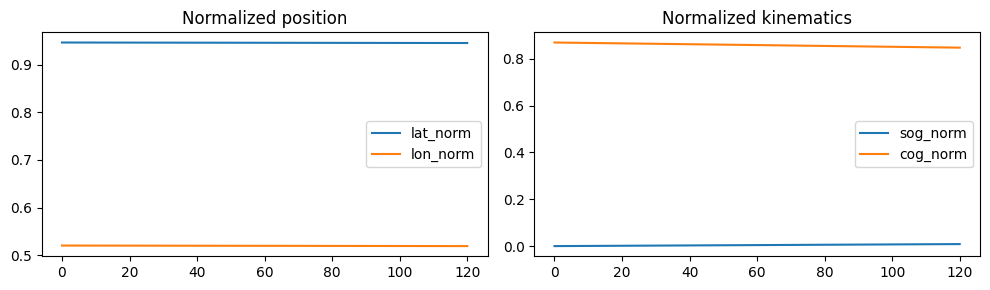

In [21]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(seq[:int(seqlen), 0].numpy(), label='lat_norm')
plt.plot(seq[:int(seqlen), 1].numpy(), label='lon_norm')
plt.legend()
plt.title('Normalized position')

plt.subplot(1, 2, 2)
plt.plot(seq[:int(seqlen), 2].numpy(), label='sog_norm')
plt.plot(seq[:int(seqlen), 3].numpy(), label='cog_norm')
plt.legend()
plt.title('Normalized kinematics')
plt.tight_layout()
plt.show()

## 3) Model Forward Sanity Check

In [22]:
model = models.TrAISformer(cf, partition_model=None).to(cf.device)
print('n_params:', sum(p.numel() for p in model.parameters()))
loader = DataLoader(train_ds, batch_size=cf.batch_size, shuffle=True)
seqs, masks, *_ = next(iter(loader))
seqs = seqs.to(cf.device)
masks = masks[:, :-1].to(cf.device)
logits, loss, loss_tuple = model(seqs, masks=masks, with_targets=True, return_loss_tuple=True)
print('logits shape:', tuple(logits.shape))
print('loss:', float(loss))
print('head losses:', [float(x.mean()) for x in loss_tuple])

n_params: 57420547
logits shape: (32, 120, 622)
loss: 19.174213409423828
head losses: [5.648096084594727, 5.67509126663208, 3.511899471282959, 4.3391289710998535]


## 4) MLflow + Early Stopping + Resume Training

In [ ]:
# Launch MLflow UI from terminal if needed:
# mlflow ui --host 0.0.0.0 --port 5000

early_cfg = EarlyStoppingConfig(max_epochs=50, patience=8, min_delta=1e-4)
trainer = TrAISformerMLflowTrainer(
    model=model,
    train_dataset=train_ds,
    valid_dataset=valid_ds,
    test_dataset=test_ds,
    config=cf,
    sample_fn=trainers.sample,
    run_dir=RUN_DIR,
    early_stop=early_cfg,
    experiment_name='trAISformer_region1',
)

RUN_TRAIN = True
if RUN_TRAIN:
    trainer.train()
    print('Training complete. Best checkpoint:', RUN_DIR / 'best_model.pt')
else:
    print('Skipped training.')

2026/02/25 17:30:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/25 17:30:54 INFO mlflow.store.db.utils: Updating database tables
2026/02/25 17:30:54 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/25 17:30:54 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/25 17:30:54 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/02/25 17:30:54 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2026/02/25 17:30:54 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2026/02/25 17:30:54 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2026/02/25 17:30:54 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2026/02/25 17:30:54 INFO alembic.runtime.migration: Running 

## 5) Post-Training Inference Sample

In [ ]:
if (RUN_DIR / 'best_model.pt').exists():
    payload = torch.load(RUN_DIR / 'best_model.pt', map_location=cf.device)
    model.load_state_dict(payload['model_state'])
model.eval()
demo_batch = next(iter(DataLoader(test_ds, batch_size=4, shuffle=True)))
demo_seqs, *_ = demo_batch
demo_init = demo_seqs[:, :cf.init_seqlen, :].to(cf.device)
with torch.no_grad():
    preds = trainers.sample(
        model,
        demo_init,
        steps=12,
        temperature=1.0,
        sample=True,
        sample_mode=cf.sample_mode,
        r_vicinity=cf.r_vicinity,
        top_k=cf.top_k,
    )
print('pred shape:', tuple(preds.shape))
print('first pred last token:', preds[0, -1].detach().cpu().numpy())

In [ ]:
p = preds[0].detach().cpu().numpy()
plt.figure(figsize=(5, 5))
plt.plot(p[:, 1], p[:, 0], marker='o', ms=2)
plt.title('Sampled normalized trajectory')
plt.xlabel('lon_norm')
plt.ylabel('lat_norm')
plt.grid(True)
plt.show()